# `mosaic(bounds=...)` - Sentinel-2 mosaics for arbitrary bounding boxes

Instead of passing an MGRS tile via `grid_id`, you can pass a `bounds` tuple to mosaic any rectangular area, including areas that intersect Sentinel-2 tile boundaries.

In [1]:
from pathlib import Path
import json

import numpy as np
from matplotlib import pyplot as plt

from s2mosaic import mosaic


def plot_rgb(array, title=None, figsize=(8, 6)):
    """Display B04/B03/B02-style arrays with a robust percentile stretch."""
    rgb = np.moveaxis(array[:3], 0, -1).astype(float)
    valid = rgb[np.isfinite(rgb) & (rgb > 0)]
    if valid.size == 0:
        raise ValueError("No positive finite pixels to display")
    lo, hi = np.nanpercentile(valid, [2, 98])
    if not np.isfinite(hi - lo) or hi <= lo:
        hi = np.nanmax(valid)
        lo = np.nanmin(valid)
    rgb_disp = np.clip((rgb - lo) / max(hi - lo, 1), 0, 1)

    plt.figure(figsize=figsize)
    plt.imshow(rgb_disp)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

## 1. Basic usage - small bounds in UTM

Bounds are `(minx, miny, maxx, maxy)` in `input_crs` and `bounds=` always fills the rectangle — for cross-CRS input (e.g. lon/lat in → UTM out) the output is the reprojected axis-aligned envelope of the rectangle (no implicit polygon mask, no nodata wedges). For best output quality, pass bounds in the local UTM zone so `input_crs == output_crs`: there's no envelope inflation, and `snap_to_source_grid=True` keeps every output pixel aligned with the native Sentinel-2 grid (zero resampling). Use lon/lat input for AOIs that genuinely span multiple UTM zones (see section 3), or use `aoi=shapely.geometry.box(*bounds)` if you specifically want the lat/lon rectangle clipped after reprojection.

In [2]:
# ~7.6km x 3.4km AOI near Perth, WA.
# UTM zone 50S (EPSG:32750) metres.
bounds = (389410, 6462290, 397010, 6465700)

array, profile = mosaic(
    bounds=bounds,
    input_crs=32750,
    snap_to_source_grid=True,
    start_year=2023,
    start_month=6,
    start_day=1,
    duration_months=2,
    bands=["B04", "B03", "B02"],
    mosaic_method="median",
    show_progress=True,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/11 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (percentile):   0%|          | 0/24 [00:00<?, ?read/s]

Shape: (3, 341, 760)
CRS:   EPSG:32750
Pixel: 10.0m


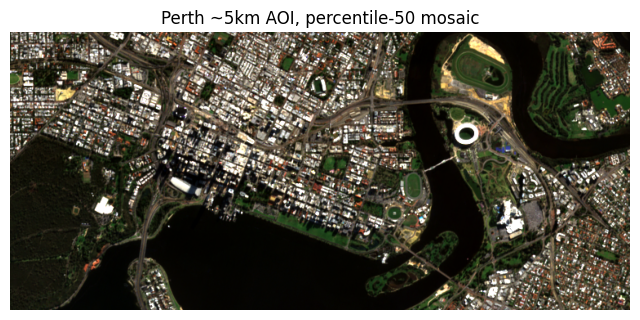

In [3]:
plot_rgb(array, "Perth ~5km AOI, percentile-50 mosaic")

## 2. Lower resolution and bilinear resampling

`resolution` is in metres of the output pixel. At 30 m, rasterio can read from COG overviews rather than the native 10 m file, which usually means much less data over the wire.

In [4]:
array, profile = mosaic(
    bounds=bounds,
    input_crs=32750,
    snap_to_source_grid=True,
    start_year=2023,
    start_month=6,
    duration_days=14,
    bands=["B04", "B03", "B02"],
    mosaic_method="mean",
    resolution=30,
    resampling_method="bilinear",
    additional_query={"eo:cloud_cover": {"lt": 50}},
    show_progress=True,
)

print(f"Shape: {array.shape}")
print(f"Pixel size: {profile['transform'].a}m")

Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/1 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (mean):   0%|          | 0/3 [00:00<?, ?read/s]

Shape: (3, 115, 254)
Pixel size: 30.0m


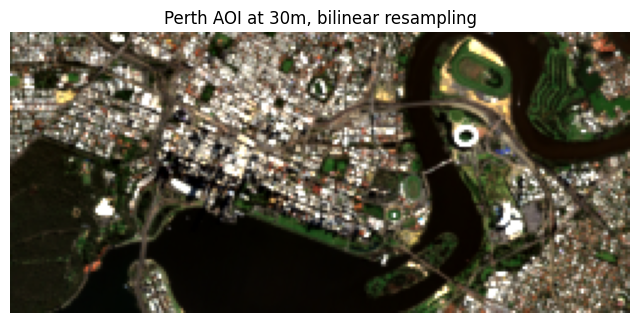

In [5]:
plot_rgb(array, "Perth AOI at 30m, bilinear resampling", figsize=(8, 8))

## 3. Cross-zone AOI - scenes from two UTM zones merged onto one output grid

Sentinel-2 tile footprints overlap, so even a small AOI near a UTM zone boundary can be covered by scenes from MGRS tiles in two different UTM zones. Bounds mode reprojects those scenes onto one chosen output grid.

This Melbourne AOI sits just east of the 144°E boundary, so it's geographically in UTM zone 55S (EPSG:32755) — that's what we pass as `input_crs` and `output_crs`. The MGRS tiles covering it span both zones (54HYC/54HYD in zone 54, 55HBT/55HBU in zone 55); scenes from zone 54 are streamed through a `WarpedVRT` onto the zone-55 output grid.

In [ ]:
# ~3.6km x 4.5km AOI west of Melbourne (Werribee area),
# near the UTM 54/55 zone boundary.
# UTM zone 55S (EPSG:32755) metres.
cross_bounds = (273370, 5796260, 277010, 5800800)

array, profile = mosaic(
    bounds=cross_bounds,
    input_crs=32755,
    snap_to_source_grid=True,
    start_year=2023,
    start_month=1,
    duration_months=1,
    bands=["B04", "B03", "B02"],
    mosaic_method="median",
    show_progress=True,
)

print(f"Shape: {array.shape}")
print(f"CRS:   {profile['crs']}")
print(f"Pixel: {profile['transform'].a}m")

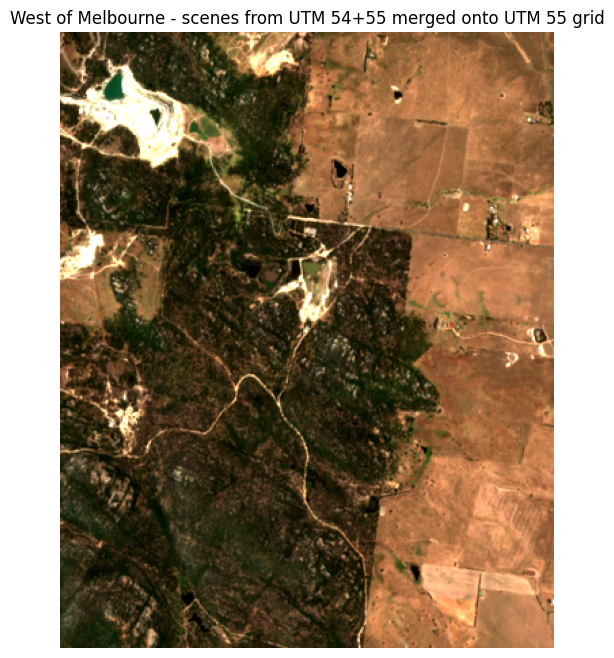

In [7]:
plot_rgb(
    array,
    "West of Melbourne - scenes from UTM 54+55 merged onto UTM 55 grid",
    figsize=(8, 8),
)

## 4. Save to disk and inspect metadata

Pass `output_dir` and the GeoTIFF is written with an auto-generated filename. A matching `.json` sidecar records the normalized request metadata. Small bounds exports are usually MB-scale, unlike full-tile grid exports.

In [8]:
result = mosaic(
    bounds=bounds,
    input_crs=32750,
    snap_to_source_grid=True,
    start_year=2023,
    start_month=6,
    duration_days=14,
    output_dir=Path("output"),
    bands=["B04", "B03", "B02"],
    mosaic_method="median",
    additional_query={"eo:cloud_cover": {"lt": 50}},
)
print(f"Saved to: {result}")

metadata_path = result.with_suffix(".json")
metadata = json.loads(metadata_path.read_text())
print(f"Metadata: {metadata_path}")
summary = {
    "mode": metadata["mode"],
    "start_date": metadata["start_date"],
    "end_date": metadata["end_date"],
}
summary.update(
    {
        key: metadata["request"][key]
        for key in ["bands", "mosaic_method", "resolution", "source"]
    }
)
print(summary)

Saved to: output/bbox-115p8296_neg31p9707_115p9104_neg31p9393_2023-06-01_to_2023-06-15_B04-B03-B02_percentile-p50_scene-valid_data_10m_OCM_MPC_f321a1af45.tif
Metadata: output/bbox-115p8296_neg31p9707_115p9104_neg31p9393_2023-06-01_to_2023-06-15_B04-B03-B02_percentile-p50_scene-valid_data_10m_OCM_MPC_f321a1af45.json
{'mode': 'bounds', 'start_date': '2023-06-01', 'end_date': '2023-06-15', 'bands': ['B04', 'B03', 'B02'], 'mosaic_method': 'percentile', 'resolution': 10, 'source': 'MPC'}
